In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import re
import string
import plotly.express as px
import nltk
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# SAMO PRI PRVOM POKRETANJU, KASNIJE MOGU DA SE ZAKOMENTARISU: 
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

<h4>Pomocne funkcije</h4>

In [13]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


def get_metrics(X, labels, name, silhouette_metric="cosine"):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return [name, n_clusters, np.nan, np.nan, np.nan]

    mask = labels != -1
    if mask.sum() < 2:
        return [name, n_clusters, np.nan, np.nan, np.nan]

    s = silhouette_score(X[mask], labels[mask], metric=silhouette_metric)
    db = davies_bouldin_score(X[mask], labels[mask])
    ch = calinski_harabasz_score(X[mask], labels[mask])
    return [name, n_clusters, s, db, ch]

<h4>Ucitavanje i uzrokovanje podataka

In [14]:
cols_to_use = ['Text', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score']
data = pd.read_csv('../Reviews.csv', usecols=cols_to_use)

data = data.dropna(subset=cols_to_use)

df, _ = train_test_split(
    data,
    train_size=10000,
    stratify=data["Score"],
    random_state=42
)

df = df.reset_index(drop=True)

print(f"Konačan broj redova za analizu: {len(df)}")

Konačan broj redova za analizu: 10000


<h4>Feature engineering

In [16]:
#izbegavanje redudarnosti izmedju numerator i denominator
df['HelpfulnessRatio'] = df['HelpfulnessNumerator'] / (df['HelpfulnessDenominator'] + 1)
print("Ciscenje teksta...")
df['Cleaned_Text'] = df['Text'].apply(clean_text)

Ciscenje teksta...


<h4>Vektorizacija i skaliranje

In [17]:
# tekstualni deo
custom_stop = list(ENGLISH_STOP_WORDS) + ['wa', 'ha', 'doe', 'ca']
tfidf = TfidfVectorizer(max_features=1000, stop_words=custom_stop, ngram_range=(1,2), min_df = 5)
X_text = tfidf.fit_transform(df['Cleaned_Text']).toarray()

# numericki deo (Helpfulness)
num_cols = ['HelpfulnessNumerator', 'HelpfulnessDenominator', 'HelpfulnessRatio']
scaler = StandardScaler()
X_num = scaler.fit_transform(df[num_cols])

# spajanje (Tekst + Brojevi)
X_combined = np.hstack((X_text, X_num))
X_final = Normalizer().fit_transform(X_combined)

print(f"Dimenzija podataka (Svi atributi): {X_final.shape}")

Dimenzija podataka (Svi atributi): (10000, 1003)


<h4>Odredjivanje optimalnog k - Elbow i Silhouette metoda

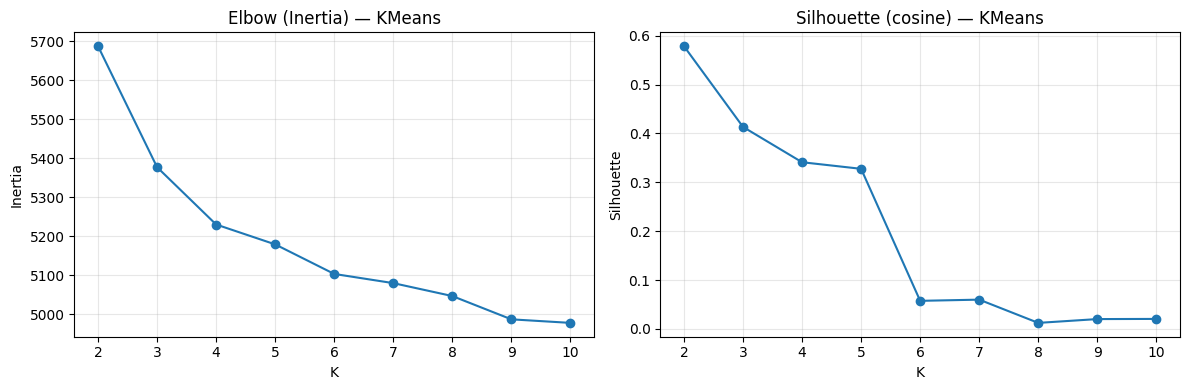

Optimalan broj klastera (po max Silhouette cosine): K=2


In [18]:
K_range = range(2, 11)
inertias = []
sil_cos = []

for k in K_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_final)
    inertias.append(km_tmp.inertia_)
    sil_cos.append(silhouette_score(X_final, labels_tmp, metric="cosine"))

# Uporedjivanje elbow i silhouette metode
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(list(K_range), inertias, marker='o')
plt.title("Elbow (Inertia) — KMeans")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(list(K_range), sil_cos, marker='o')
plt.title("Silhouette (cosine) — KMeans")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("elbow_silhouette_all.png", dpi=150)
plt.show()

optimal_k = list(K_range)[int(np.argmax(sil_cos))]
print(f"Optimalan broj klastera (po max Silhouette cosine): K={optimal_k}")

<h3>Klasterovanje - svi algoritmi sa optimalnim k

In [20]:
all_results = []

# KLASTEROVANJE - ALGORITMI SA OPTIMALNIM K

km = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_km = km.fit_predict(X_final)
all_results.append(get_metrics(X_final, labels_km, f"KMeans(k={optimal_k})", silhouette_metric="cosine"))

mb = MiniBatchKMeans(n_clusters=optimal_k, random_state=42, batch_size=100, n_init=10)
labels_mb = mb.fit_predict(X_final)
all_results.append(get_metrics(X_final, labels_mb, f"MiniBatchKMeans(k={optimal_k})", silhouette_metric="cosine"))

agg = AgglomerativeClustering(n_clusters=optimal_k)
labels_agg = agg.fit_predict(X_final)
all_results.append(get_metrics(X_final, labels_agg, f"Agglomerative(k={optimal_k})", silhouette_metric="cosine"))


spec = SpectralClustering(n_clusters=optimal_k, affinity='nearest_neighbors', random_state=42)
labels_spec = spec.fit_predict(X_final)
all_results.append(get_metrics(X_final, labels_spec, f"Spectral(k={optimal_k})", silhouette_metric="cosine"))

#nema fiksan k
db_model = DBSCAN(eps=0.4, min_samples=3)
labels_db = db.fit_predict(X_final)
all_results.append(get_metrics(X_final, labels_db, "DBSCAN(eps=0.4,min_samples=3)", silhouette_metric="cosine"))

<h3>Klasterovanje - svi algoritmi sa k = 5 (domenski motivisano)

In [21]:
km5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_km5 = km5.fit_predict(X_final)
all_results.append(get_metrics(X_final, labels_km5, "KMeans(k=5)", silhouette_metric="cosine"))

mb5 = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=100, n_init=10)
labels_mb5 = mb5.fit_predict(X_final)
all_results.append(get_metrics(X_final, labels_mb5, "MiniBatchKMeans(k=5)", silhouette_metric="cosine"))

agg5 = AgglomerativeClustering(n_clusters=5)
labels_agg5 = agg5.fit_predict(X_final)
all_results.append(get_metrics(X_final, labels_agg5, "Agglomerative(k=5)", silhouette_metric="cosine"))

spec5 = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', random_state=42)
labels_spec5 = spec5.fit_predict(X_final)
all_results.append(get_metrics(X_final, labels_spec5, "Spectral(k=5)", silhouette_metric="cosine"))


<h4>Prikaz podataka

In [ ]:
df_res = pd.DataFrame(all_results, columns=['Algoritam', "n_clusters", 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'])

print("\n--- REZULTATI: SVI ATRIBUTI (NUMERIČKI + TEKST) ---")
print(df_res.to_string(index=False))

df_res.to_csv("rezultati_all.csv", index=False)
print("\nSacuvano: rezultati_all.csv")

<h4>Analiza DBSCAN - raspodela klastera

In [22]:
print("\n=== DBSCAN raspodela klastera (ukljucujuci sum = -1) ===")
dbscan_counts = pd.Series(labels_db).value_counts().sort_index()
print(dbscan_counts)
n_noise = (labels_db == -1).sum()
n_total = len(labels_db)
print(f"\nBroj sum tacaka (label=-1): {n_noise} ({100*n_noise/n_total:.1f}%)")
print(f"Napomena: Visok Silhouette score kod DBSCAN moze biti misleading")
print(f"ako jedan klaster sadrzi veliku vecinu tacaka.")


=== DBSCAN raspodela klastera (ukljucujuci sum = -1) ===
-1    9632
 0     340
 1       3
 2       3
 3       4
 4       3
 5       3
 6       3
 7       3
 8       3
 9       3
Name: count, dtype: int64

Broj sum tacaka (label=-1): 9632 (96.3%)
Napomena: Visok Silhouette score kod DBSCAN moze biti misleading
ako jedan klaster sadrzi veliku vecinu tacaka.


<h4>Analiza KMeans K=optimal - CROSSTAB I TOP RECI

In [23]:
df["cluster_opt"] = labels_km
df["cluster_k5"] = labels_km5

print(f"\n=== Crosstab: cluster (K={optimal_k}) × Score (brojevi) ===")
print(pd.crosstab(df["cluster_opt"], df["Score"]))

print(f"\n=== Crosstab: cluster (K={optimal_k}) × Score (procenti po klasteru) ===")
ct_score_opt = pd.crosstab(df["cluster_opt"], df["Score"], normalize="index")
print(ct_score_opt)

print("\n=== Crosstab: cluster (K=5) × Score (procenti po klasteru) ===")
ct_score_k5 = pd.crosstab(df["cluster_k5"], df["Score"], normalize="index")
print(ct_score_k5)

# Top reci po klasterima - optimalni K
feature_names = np.array(tfidf.get_feature_names_out())
print(f"\nTop reci po klasterima (K={optimal_k}):")
text_centers_opt = km.cluster_centers_[:, :1000]
for i in range(optimal_k):
    top_indices = text_centers_opt[i].argsort()[::-1][:10]
    top_words = feature_names[top_indices]
    print(f"\nKlaster {i}: {', '.join(top_words)}")

# Top reci po klasterima - K=5
print("\nTop reci po klasterima (K=5):")
text_centers_k5 = km5.cluster_centers_[:, :1000]
for i in range(5):
    top_indices = text_centers_k5[i].argsort()[::-1][:10]
    top_words = feature_names[top_indices]
    print(f"\nKlaster {i}: {', '.join(top_words)}")

# Statistika po klasterima
print(f"\nStatistika po klasterima (K={optimal_k}):")
statistika_opt = df.groupby('cluster_opt')[['Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'HelpfulnessRatio']].mean()
print(statistika_opt)

print("\nStatistika po klasterima (K=5):")
statistika_k5 = df.groupby('cluster_k5')[['Score', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'HelpfulnessRatio']].mean()
print(statistika_k5)

print("\nBroj recenzija po klasterima (K=optimal):")
print(df['cluster_opt'].value_counts())

print("\nBroj recenzija po klasterima (K=5):")
print(df['cluster_k5'].value_counts())



=== Crosstab: cluster (K=2) × Score (brojevi) ===
Score          1    2    3    4     5
cluster_opt                          
0            511  244  294  580  2871
1            408  280  456  839  3517

=== Crosstab: cluster (K=2) × Score (procenti po klasteru) ===
Score               1         2         3         4         5
cluster_opt                                                  
0            0.113556  0.054222  0.065333  0.128889  0.638000
1            0.074182  0.050909  0.082909  0.152545  0.639455

=== Crosstab: cluster (K=5) × Score (procenti po klasteru) ===
Score              1         2         3         4         5
cluster_k5                                                  
0           0.206349  0.109127  0.150794  0.136905  0.396825
1           0.058056  0.046142  0.080938  0.156581  0.658283
2           0.067754  0.037681  0.053623  0.143116  0.697826
3           0.162562  0.064039  0.058292  0.096059  0.619048
4           0.534783  0.186957  0.117391  0.043478  0.1

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\draga\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\draga\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Konačan broj redova za analizu: 10000
Ciscenje teksta...
Dimenzija podataka (Svi atributi): (10000, 1003)


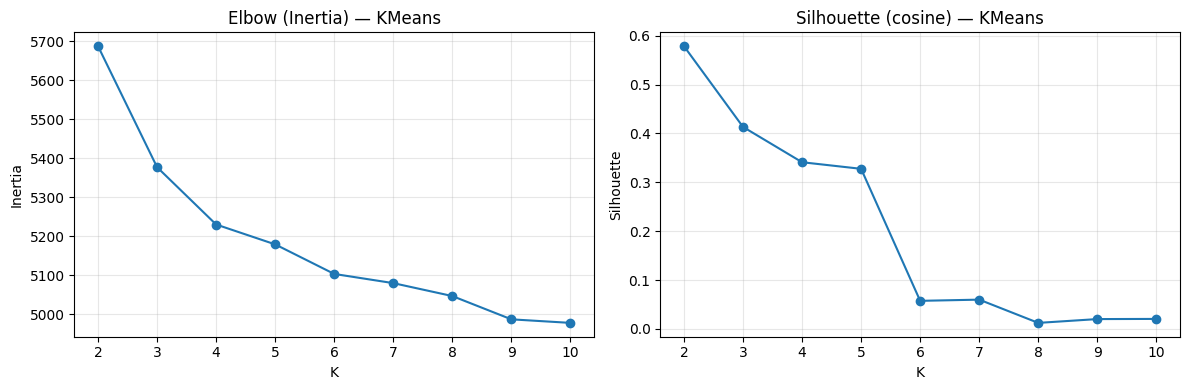

Optimalan broj klastera (po max Silhouette cosine): K=2

--- Klasterovanje sa K=5 (domenski motivisano) ---

--- REZULTATI: SVI ATRIBUTI (NUMERIČKI + TEKST) ---
                    Algoritam  n_clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz
                  KMeans(k=2)           2    0.578688        1.176344        7015.814000
         MiniBatchKMeans(k=2)           2    0.578601        1.176628        7015.413152
           Agglomerative(k=2)           2    0.556294        1.217574        6569.698235
                Spectral(k=2)           2    0.576750        1.178325        6965.384549
DBSCAN(eps=0.4,min_samples=3)          10    0.588585        0.313749          40.264382
                  KMeans(k=5)           5    0.327635        2.730862        2170.837753
         MiniBatchKMeans(k=5)           5    0.092258        4.529490        2094.981236
           Agglomerative(k=5)           5    0.252802        2.417809        2108.738436
                Spectral(k=5)         

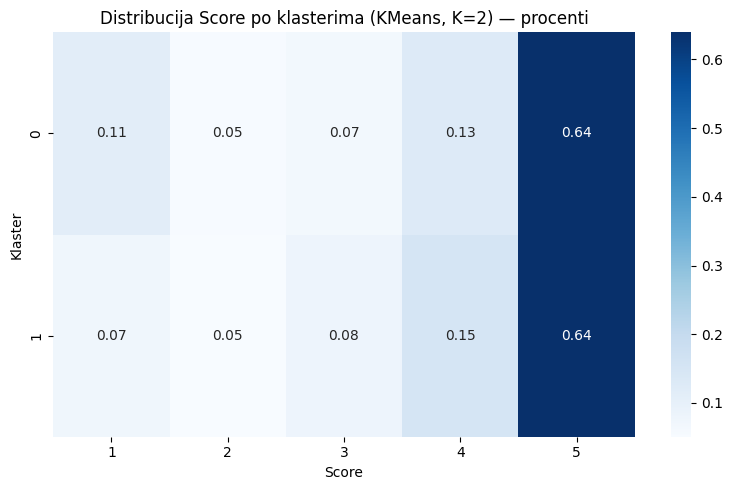

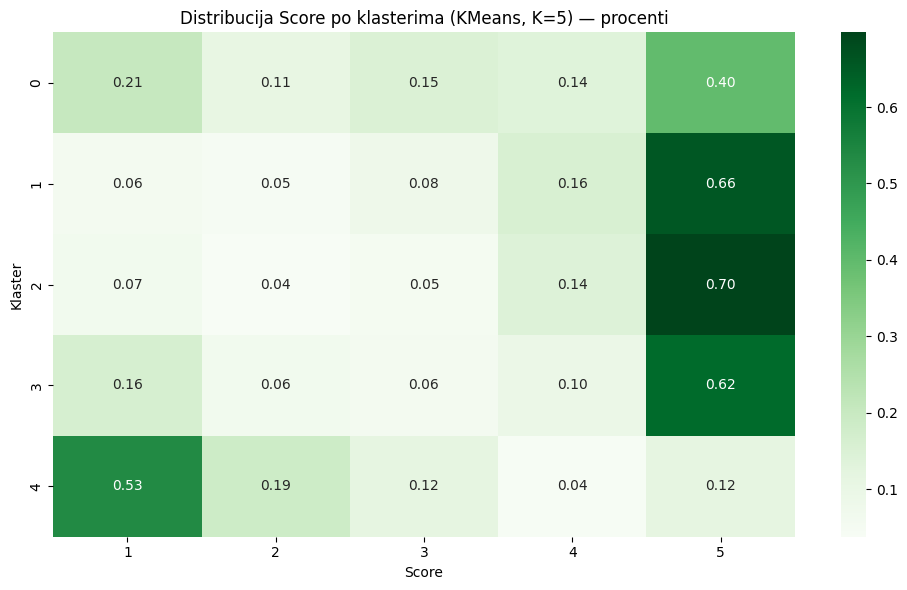

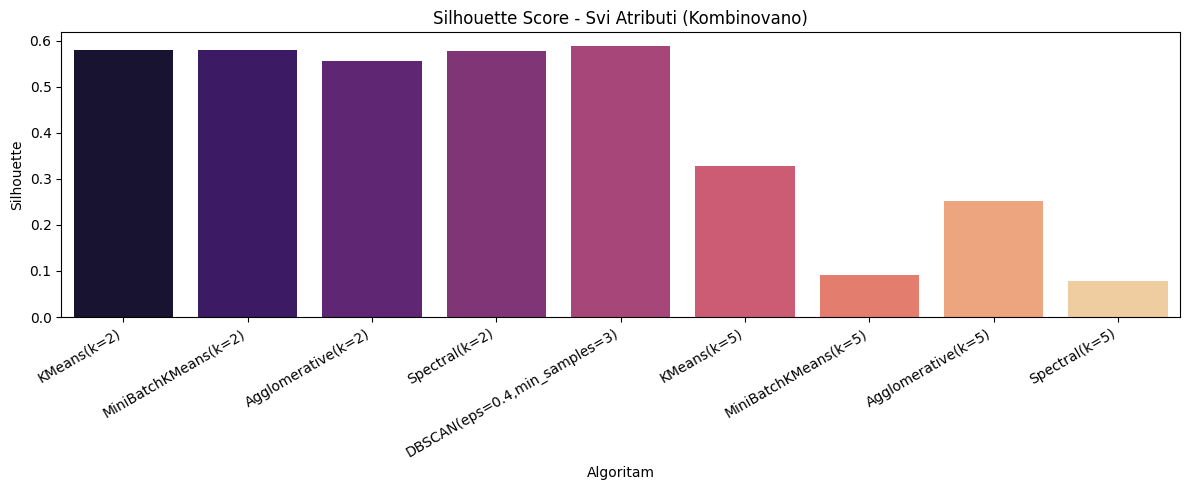

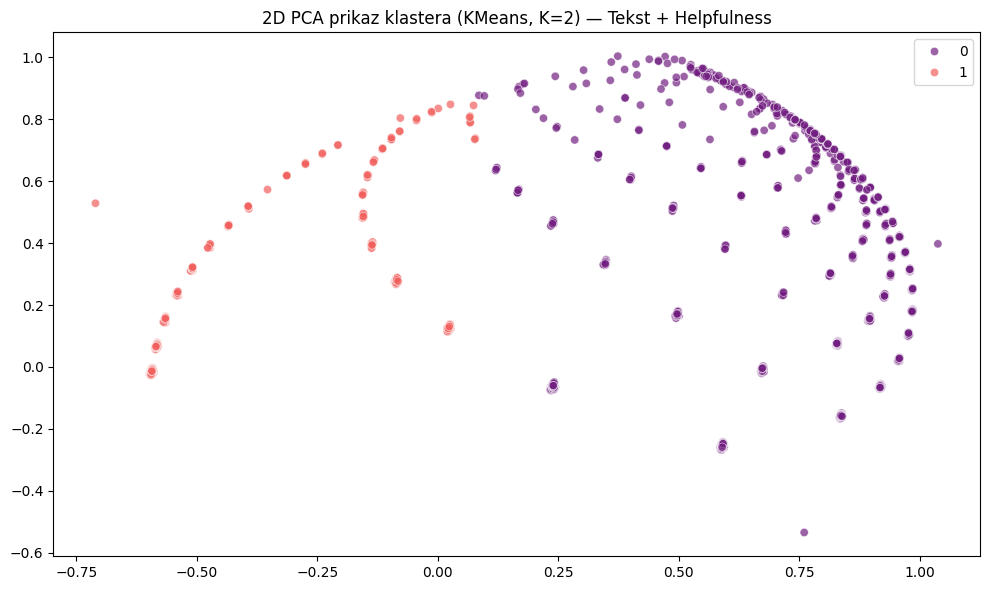

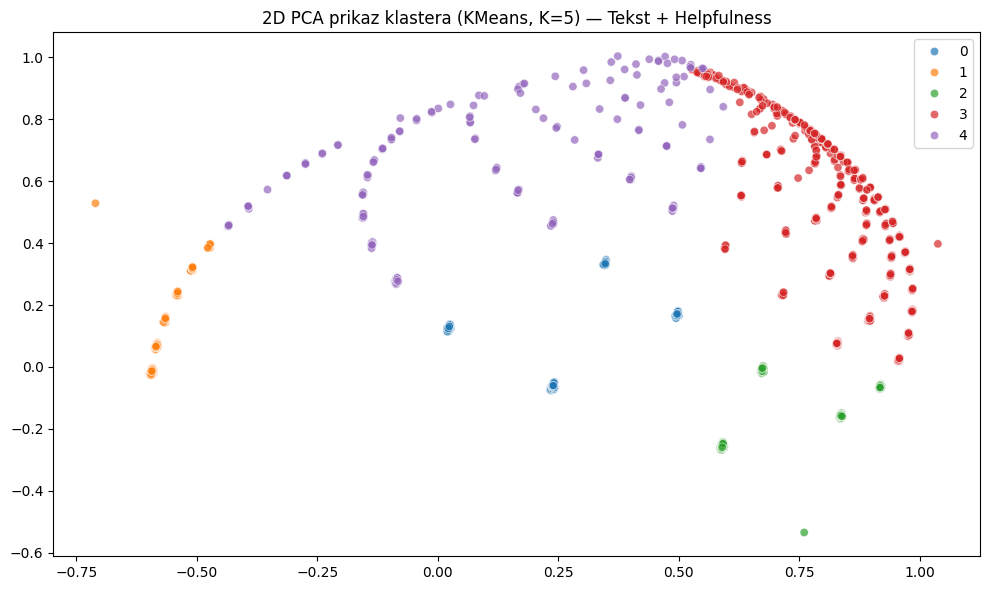


t-SNE vizualizacija (moze potrajati ~2-3 minuta)...


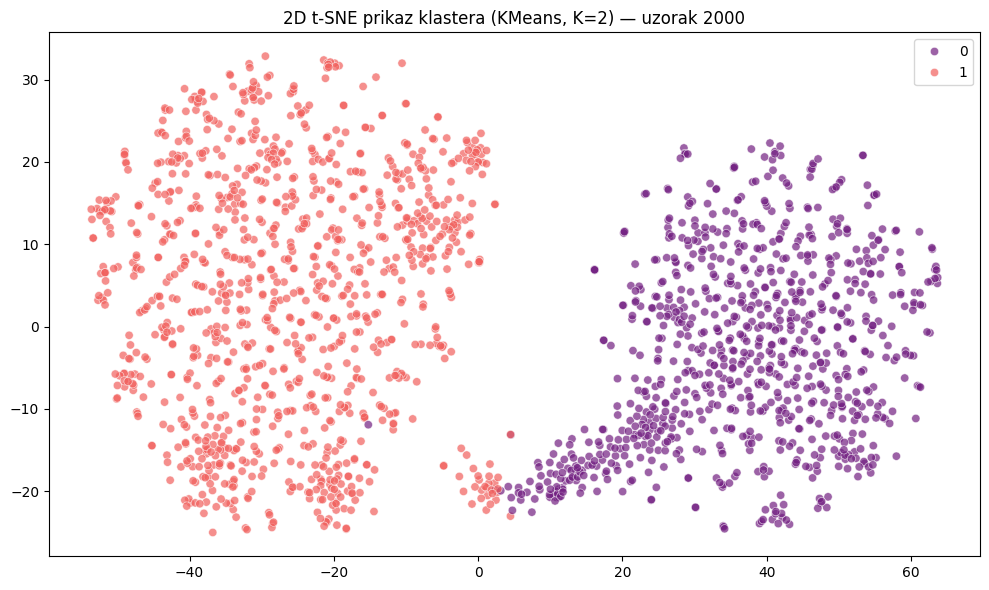

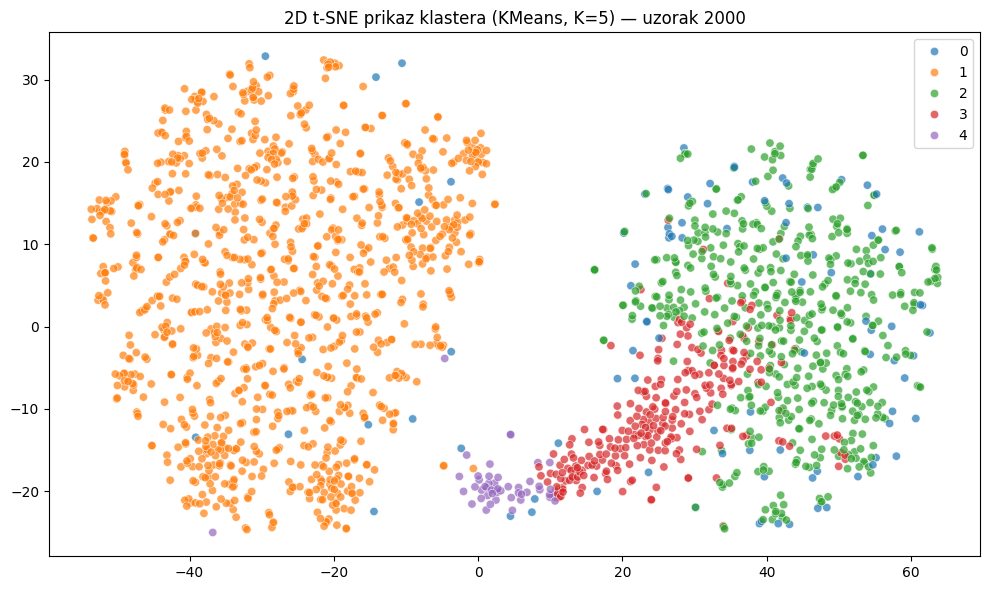

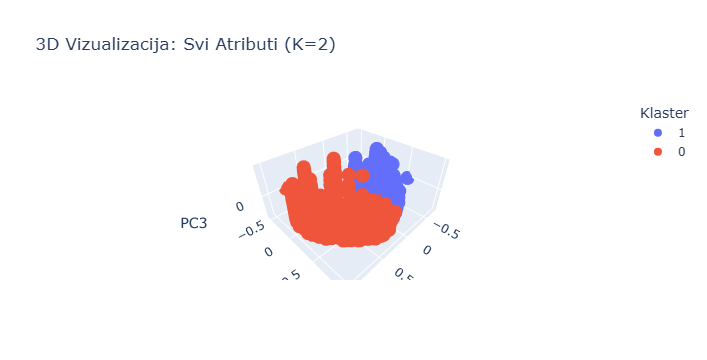

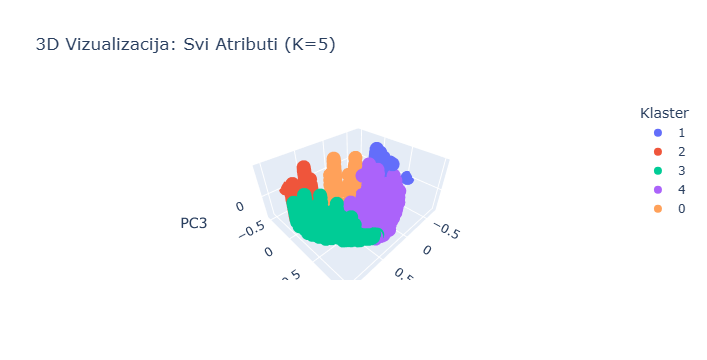


Gotovo! Svi grafici su sacuvani kao PNG fajlovi.


In [10]:


# ============================================================
# ANALIZA DBSCAN - RASPODELA KLASTERA
# ============================================================



# ============================================================
# ANALIZA KMeans K=optimal - CROSSTAB I TOP RECI
# ============================================================


# ============================================================
# VIZUALIZACIJE
# ============================================================

# --- Heatmap Score distribucija - optimalni K ---
plt.figure(figsize=(8, 5))
sns.heatmap(ct_score_opt, annot=True, fmt=".2f", cmap="Blues")
plt.title(f"Distribucija Score po klasterima (KMeans, K={optimal_k}) — procenti")
plt.xlabel("Score")
plt.ylabel("Klaster")
plt.tight_layout()
plt.savefig("heatmap_score_opt.png", dpi=150)
plt.show()

# --- Heatmap Score distribucija - K=5 ---
plt.figure(figsize=(10, 6))
sns.heatmap(ct_score_k5, annot=True, fmt=".2f", cmap="Greens")
plt.title("Distribucija Score po klasterima (KMeans, K=5) — procenti")
plt.xlabel("Score")
plt.ylabel("Klaster")
plt.tight_layout()
plt.savefig("heatmap_score_k5.png", dpi=150)
plt.show()

# --- Silhouette barplot - svi algoritmi ---
plt.figure(figsize=(12, 5))
sns.barplot(x='Algoritam', y='Silhouette', data=df_res, hue='Algoritam', palette='magma', legend=False)
plt.title('Silhouette Score - Svi Atributi (Kombinovano)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("silhouette_all.png", dpi=150)
plt.show()

# --- 2D PCA Vizualizacija - optimalni K ---
pca_2d = PCA(n_components=2)
coords_pca = pca_2d.fit_transform(X_final)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=coords_pca[:, 0], y=coords_pca[:, 1], hue=labels_km, palette='magma', alpha=0.7)
plt.title(f"2D PCA prikaz klastera (KMeans, K={optimal_k}) — Tekst + Helpfulness")
plt.tight_layout()
plt.savefig("pca_2d_opt.png", dpi=150)
plt.show()

# --- 2D PCA Vizualizacija - K=5 ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=coords_pca[:, 0], y=coords_pca[:, 1], hue=labels_km5, palette='tab10', alpha=0.7)
plt.title("2D PCA prikaz klastera (KMeans, K=5) — Tekst + Helpfulness")
plt.tight_layout()
plt.savefig("pca_2d_k5.png", dpi=150)
plt.show()

# --- 2D t-SNE Vizualizacija (na uzorku od 2000 zbog brzine) ---
print("\nt-SNE vizualizacija (moze potrajati ~2-3 minuta)...")
sample_idx = np.random.choice(len(X_final), size=2000, replace=False)
X_tsne_sample = X_final[sample_idx]
labels_tsne_opt = labels_km[sample_idx]
labels_tsne_k5 = labels_km5[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords_tsne = tsne.fit_transform(X_tsne_sample)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=coords_tsne[:, 0], y=coords_tsne[:, 1], hue=labels_tsne_opt, palette='magma', alpha=0.7)
plt.title(f"2D t-SNE prikaz klastera (KMeans, K={optimal_k}) — uzorak 2000")
plt.tight_layout()
plt.savefig("tsne_2d_opt.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=coords_tsne[:, 0], y=coords_tsne[:, 1], hue=labels_tsne_k5, palette='tab10', alpha=0.7)
plt.title("2D t-SNE prikaz klastera (KMeans, K=5) — uzorak 2000")
plt.tight_layout()
plt.savefig("tsne_2d_k5.png", dpi=150)
plt.show()

# --- 3D Vizualizacija - optimalni K ---
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_final)
df_3d = pd.DataFrame(X_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d['Klaster'] = labels_km.astype(str)
df_3d['Snippet'] = df['Text'].str[:50]

fig = px.scatter_3d(
    df_3d, x='PC1', y='PC2', z='PC3',
    color='Klaster',
    title=f"3D Vizualizacija: Svi Atributi (K={optimal_k})",
    hover_data=['Snippet']
)
fig.show()

# --- 3D Vizualizacija - K=5 ---
df_3d_k5 = pd.DataFrame(X_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d_k5['Klaster'] = labels_km5.astype(str)
df_3d_k5['Snippet'] = df['Text'].str[:50]

fig5 = px.scatter_3d(
    df_3d_k5, x='PC1', y='PC2', z='PC3',
    color='Klaster',
    title="3D Vizualizacija: Svi Atributi (K=5)",
    hover_data=['Snippet']
)
fig5.show()

print("\nGotovo! Svi grafici su sacuvani kao PNG fajlovi.")
